In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 시스템이 Mac일 경우 Apple 기본 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'

# 마이너 경고 제거 (minus 부호 깨짐 방지)
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("gdp_co2_by_country_v2.csv")

print(df.head())
print(df.columns)

  Country Name Country Code  Year  Population    Pop Log Pop Outliers  \
0  Afghanistan          AFG  1961   9214082.0  16.036244  not outlier   
1  Afghanistan          AFG  1962   9404411.0  16.056689  not outlier   
2  Afghanistan          AFG  1963   9604491.0  16.077741  not outlier   
3  Afghanistan          AFG  1964   9814318.0  16.099353  not outlier   
4  Afghanistan          AFG  1965  10036003.0  16.121690  not outlier   

  Pop Category    CO2      CO2 %  Cumulative CO2  ...  CO2 Outliers  \
0       1M-10M  0.491        NaN         235.001  ...         False   
1       1M-10M  0.689  40.325866         235.001  ...         False   
2       1M-10M  0.707   2.612482         235.001  ...         False   
3       1M-10M  0.839  18.670438         235.001  ...         False   
4     10M-100M  1.007  20.023838         235.001  ...         False   

  Emissions Category    GDP USD  GDP USD Log      GDP %  GDP % Winsor  \
0           Moderate  308.31827     5.734371 -10.119484    -1

In [5]:
df_cleaned = df.dropna(subset=['CO2 %', 'GDP %'])
df_cleaned

,Country Name,Country Code,Year,Population,Pop Log,Pop Outliers,Pop Category,CO2,CO2 %,Cumulative CO2,...,CO2 Outliers,Emissions Category,GDP USD,GDP USD Log,GDP %,GDP % Winsor,GDP Per Capita,GDP Category,CO2 Per GDP,Per Capita CO2 (kg)
1,Afghanistan,AFG,1962,9404411.0,16.056689,not outlier,1M-10M,0.689,40.325866,235.001,...,False,Moderate,308.318270,5.734371,-10.119484,-10.119484,0.000033,Low GDP,0.002235,0.000073
2,Afghanistan,AFG,1963,9604491.0,16.077741,not outlier,1M-10M,0.707,2.612482,235.001,...,False,Moderate,308.318270,5.734371,-10.119484,-10.119484,0.000032,Low GDP,0.002293,0.000074
3,Afghanistan,AFG,1964,9814318.0,16.099353,not outlier,1M-10M,0.839,18.670438,235.001,...,False,Moderate,308.318270,5.734371,-10.119484,-10.119484,0.000031,Low GDP,0.002721,0.000085
4,Afghanistan,AFG,1965,10036003.0,16.121690,not outlier,10M-100M,1.007,20.023838,235.001,...,False,Moderate,308.318270,5.734371,-10.119484,-10.119484,0.000031,Low GDP,0.003266,0.000100
5,Afghanistan,AFG,1966,10266397.0,16.144387,not outlier,10M-100M,1.091,8.341609,235.001,...,False,Moderate,308.318270,5.734371,-10.119484,-10.119484,0.000030,Low GDP,0.003539,0.000106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12439,Zimbabwe,ZWE,2019,15271377.0,16.541491,not outlier,10M-100M,10.263,-8.406961,672.114,...,False,High,1350.309851,7.208830,-7.785580,-7.785580,0.000088,Middle GDP,0.007600,0.000672
12440,Zimbabwe,ZWE,2020,15526888.0,16.558084,not outlier,10M-100M,8.495,-17.226932,672.114,...,False,High,1224.272314,7.110918,-9.333971,-9.333971,0.000079,Middle GDP,0.006939,0.000547
12441,Zimbabwe,ZWE,2021,15797220.0,16.575345,not outlier,10M-100M,10.204,20.117716,672.114,...,False,High,1305.220113,7.174893,6.611911,6.611911,0.000083,Middle GDP,0.007818,0.000646
12442,Zimbabwe,ZWE,2022,16069061.0,16.592406,not outlier,10M-100M,10.425,2.165817,672.114,...,False,High,1361.914530,7.217381,4.343667,4.343667,0.000085,Middle GDP,0.007655,0.000649


In [6]:
columns_to_keep_for_full_analysis = [
    'Country Name', 'Country Code', 'Year', 'Population', 'Pop Category',
    'CO2', 'CO2 %', 'Per Capita CO2 (kg)', 'CO2 Log', 'Emissions Category',
    'GDP USD', 'GDP %', 'GDP Per Capita', 'GDP USD Log', 'GDP Category'
]
df_full_analysis = df_cleaned[columns_to_keep_for_full_analysis]
df_full_analysis

,Country Name,Country Code,Year,Population,Pop Category,CO2,CO2 %,Per Capita CO2 (kg),CO2 Log,Emissions Category,GDP USD,GDP %,GDP Per Capita,GDP USD Log,GDP Category
1,Afghanistan,AFG,1962,9404411.0,1M-10M,0.689,40.325866,0.000073,0.524137,Moderate,308.318270,-10.119484,0.000033,5.734371,Low GDP
2,Afghanistan,AFG,1963,9604491.0,1M-10M,0.707,2.612482,0.000074,0.534737,Moderate,308.318270,-10.119484,0.000032,5.734371,Low GDP
3,Afghanistan,AFG,1964,9814318.0,1M-10M,0.839,18.670438,0.000085,0.609222,Moderate,308.318270,-10.119484,0.000031,5.734371,Low GDP
4,Afghanistan,AFG,1965,10036003.0,10M-100M,1.007,20.023838,0.000100,0.696641,Moderate,308.318270,-10.119484,0.000031,5.734371,Low GDP
5,Afghanistan,AFG,1966,10266397.0,10M-100M,1.091,8.341609,0.000106,0.737642,Moderate,308.318270,-10.119484,0.000030,5.734371,Low GDP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12439,Zimbabwe,ZWE,2019,15271377.0,10M-100M,10.263,-8.406961,0.000672,2.421523,High,1350.309851,-7.785580,0.000088,7.208830,Middle GDP
12440,Zimbabwe,ZWE,2020,15526888.0,10M-100M,8.495,-17.226932,0.000547,2.250765,High,1224.272314,-9.333971,0.000079,7.110918,Middle GDP
12441,Zimbabwe,ZWE,2021,15797220.0,10M-100M,10.204,20.117716,0.000646,2.416271,High,1305.220113,6.611911,0.000083,7.174893,Middle GDP
12442,Zimbabwe,ZWE,2022,16069061.0,10M-100M,10.425,2.165817,0.000649,2.435804,High,1361.914530,4.343667,0.000085,7.217381,Middle GDP


In [7]:
gdp_co2_correlation_by_country = df_cleaned.groupby('Country Name')[['GDP USD', 'CO2']].corr().unstack().iloc[:,1]
gdp_co2_correlation_by_country.name = 'GDP_CO2_Correlation'

gdp_per_capita_co2_per_capita_correlation_by_country = df_cleaned.groupby('Country Name')[['GDP Per Capita', 'Per Capita CO2 (kg)']].corr().unstack().iloc[:,1]
gdp_per_capita_co2_per_capita_correlation_by_country.name = 'GDP_Per_Capita_CO2_Per_Capita_Correlation'

correlations_df = pd.DataFrame({
    'GDP_CO2_Correlation': gdp_co2_correlation_by_country,
    'GDP_Per_Capita_CO2_Per_Capita_Correlation': gdp_per_capita_co2_per_capita_correlation_by_country
}).reset_index()

correlations_df

,Country Name,GDP_CO2_Correlation,GDP_Per_Capita_CO2_Per_Capita_Correlation
0,Afghanistan,0.878499,-0.139085
1,Albania,0.145799,0.092586
2,Algeria,0.877462,-0.594108
3,Andorra,0.563584,0.475197
4,Angola,0.083303,-0.650092
...,...,...,...
198,Viet Nam,0.980726,0.967355
199,West Bank and Gaza,0.833129,-0.447222
200,"Yemen, Rep.",0.462958,-0.058895
201,Zambia,0.781957,0.958207


In [12]:
latest_category_info = df_cleaned.sort_values('Year', ascending=True).groupby('Country Name').last().reset_index()
category_cols = ['Country Name', 'Pop Category', 'Emissions Category', 'GDP Category']
latest_category_info = latest_category_info[category_cols]

correlations_with_categories_df = pd.merge(correlations_df, latest_category_info, on='Country Name', how='left')
correlations_with_categories_df

,Country Name,GDP_CO2_Correlation,GDP_Per_Capita_CO2_Per_Capita_Correlation,Pop Category,Emissions Category,GDP Category
0,Afghanistan,0.878499,-0.139085,10M-100M,Moderate,Low GDP
1,Albania,0.145799,0.092586,1M-10M,Moderate,Middle GDP
2,Algeria,0.877462,-0.594108,10M-100M,Very High,Middle GDP
3,Andorra,0.563584,0.475197,<1M,Low,High GDP
4,Angola,0.083303,-0.650092,10M-100M,High,Middle GDP
...,...,...,...,...,...,...
198,Viet Nam,0.980726,0.967355,100M-1B,Very High,Middle GDP
199,West Bank and Gaza,0.833129,-0.447222,1M-10M,Low,Middle GDP
200,"Yemen, Rep.",0.462958,-0.058895,10M-100M,High,Low GDP
201,Zambia,0.781957,0.958207,10M-100M,Moderate,Middle GDP


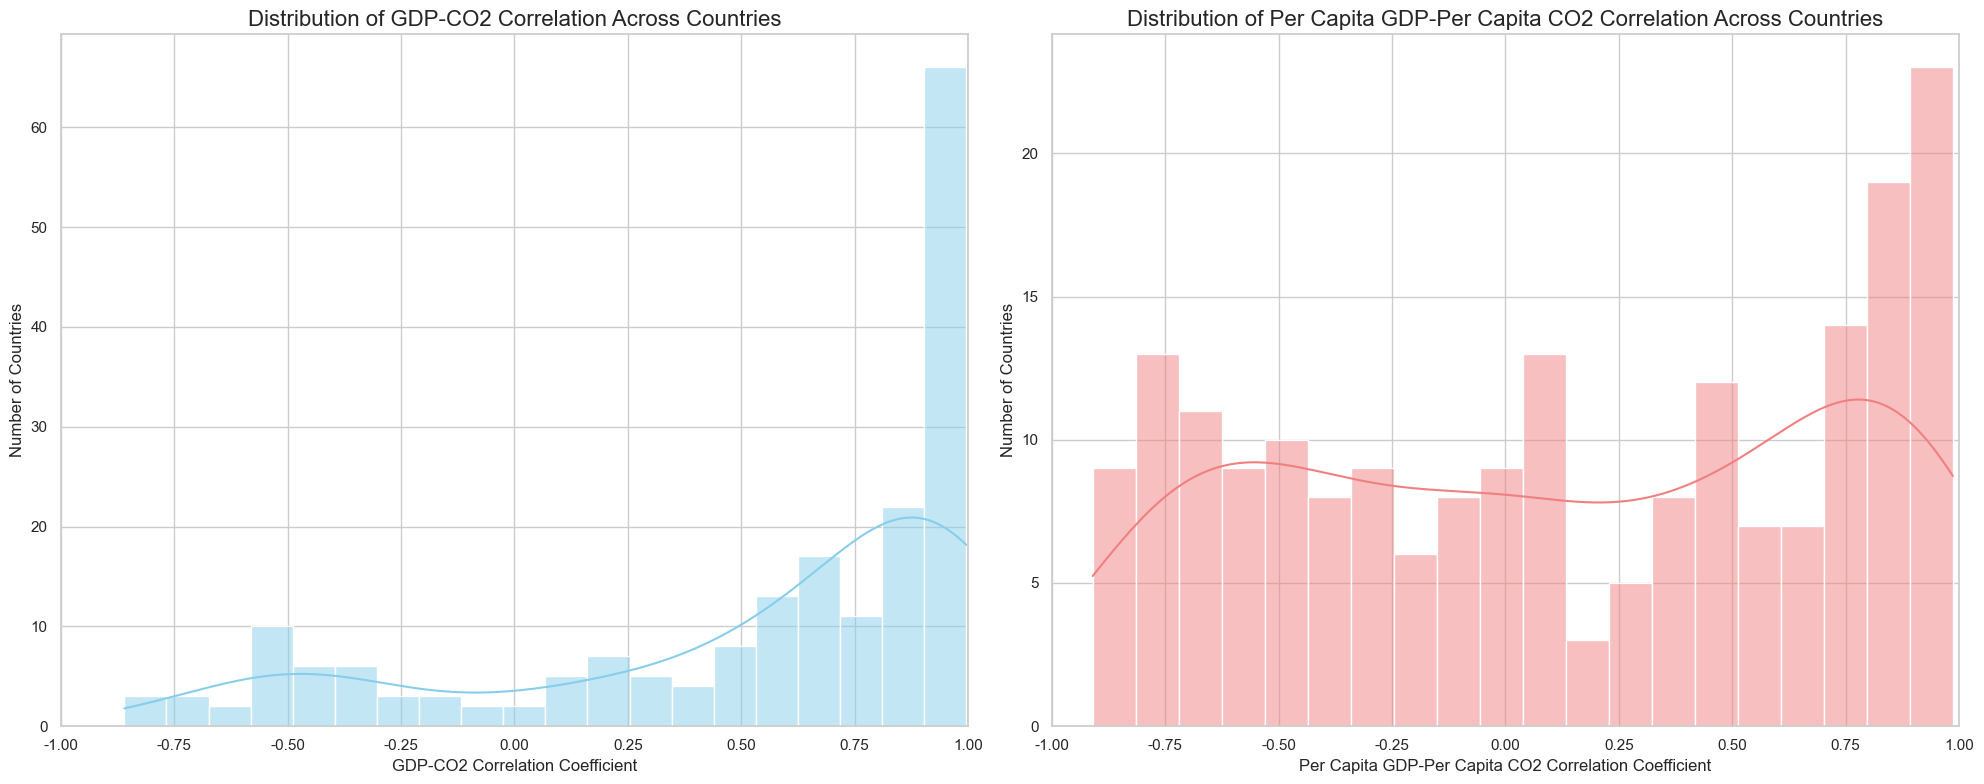

In [14]:
sns.set_theme(style="whitegrid") # 시각화 스타일 설정

fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # figsize 확장

# 총 GDP-CO2 상관관계 분포 히스토그램
sns.histplot(correlations_df['GDP_CO2_Correlation'], kde=True, ax=axes[0], bins=20, color='skyblue')
axes[0].set_title('Distribution of GDP-CO2 Correlation Across Countries', fontsize=16)
axes[0].set_xlabel('GDP-CO2 Correlation Coefficient', fontsize=12)
axes[0].set_ylabel('Number of Countries', fontsize=12)
axes[0].set_xlim([-1, 1])

# 1인당 GDP-1인당 CO2 상관관계 분포 히스토그램
sns.histplot(correlations_df['GDP_Per_Capita_CO2_Per_Capita_Correlation'], kde=True, ax=axes[1], bins=20, color='lightcoral')
axes[1].set_title('Distribution of Per Capita GDP-Per Capita CO2 Correlation Across Countries', fontsize=16)
axes[1].set_xlabel('Per Capita GDP-Per Capita CO2 Correlation Coefficient', fontsize=12)
axes[1].set_ylabel('Number of Countries', fontsize=12)
axes[1].set_xlim([-1, 1])

plt.tight_layout()
plt.show()

In [16]:
# representative_countries 딕셔너리에 있는 국가들의 목록을 가져옵니다.
selected_country_names = list(representative_countries.keys())

# correlations_df에서 해당 국가들의 GDP_CO2_Correlation 값을 필터링합니다.
correlation_verification = correlations_df[correlations_df['Country Name'].isin(selected_country_names)]

# 결과를 상관계수 기준으로 정렬하여 출력합니다.
print("Representative Countries - GDP-CO2 Correlation Verification:")
correlation_verification

NameError: name 'representative_countries' is not defined

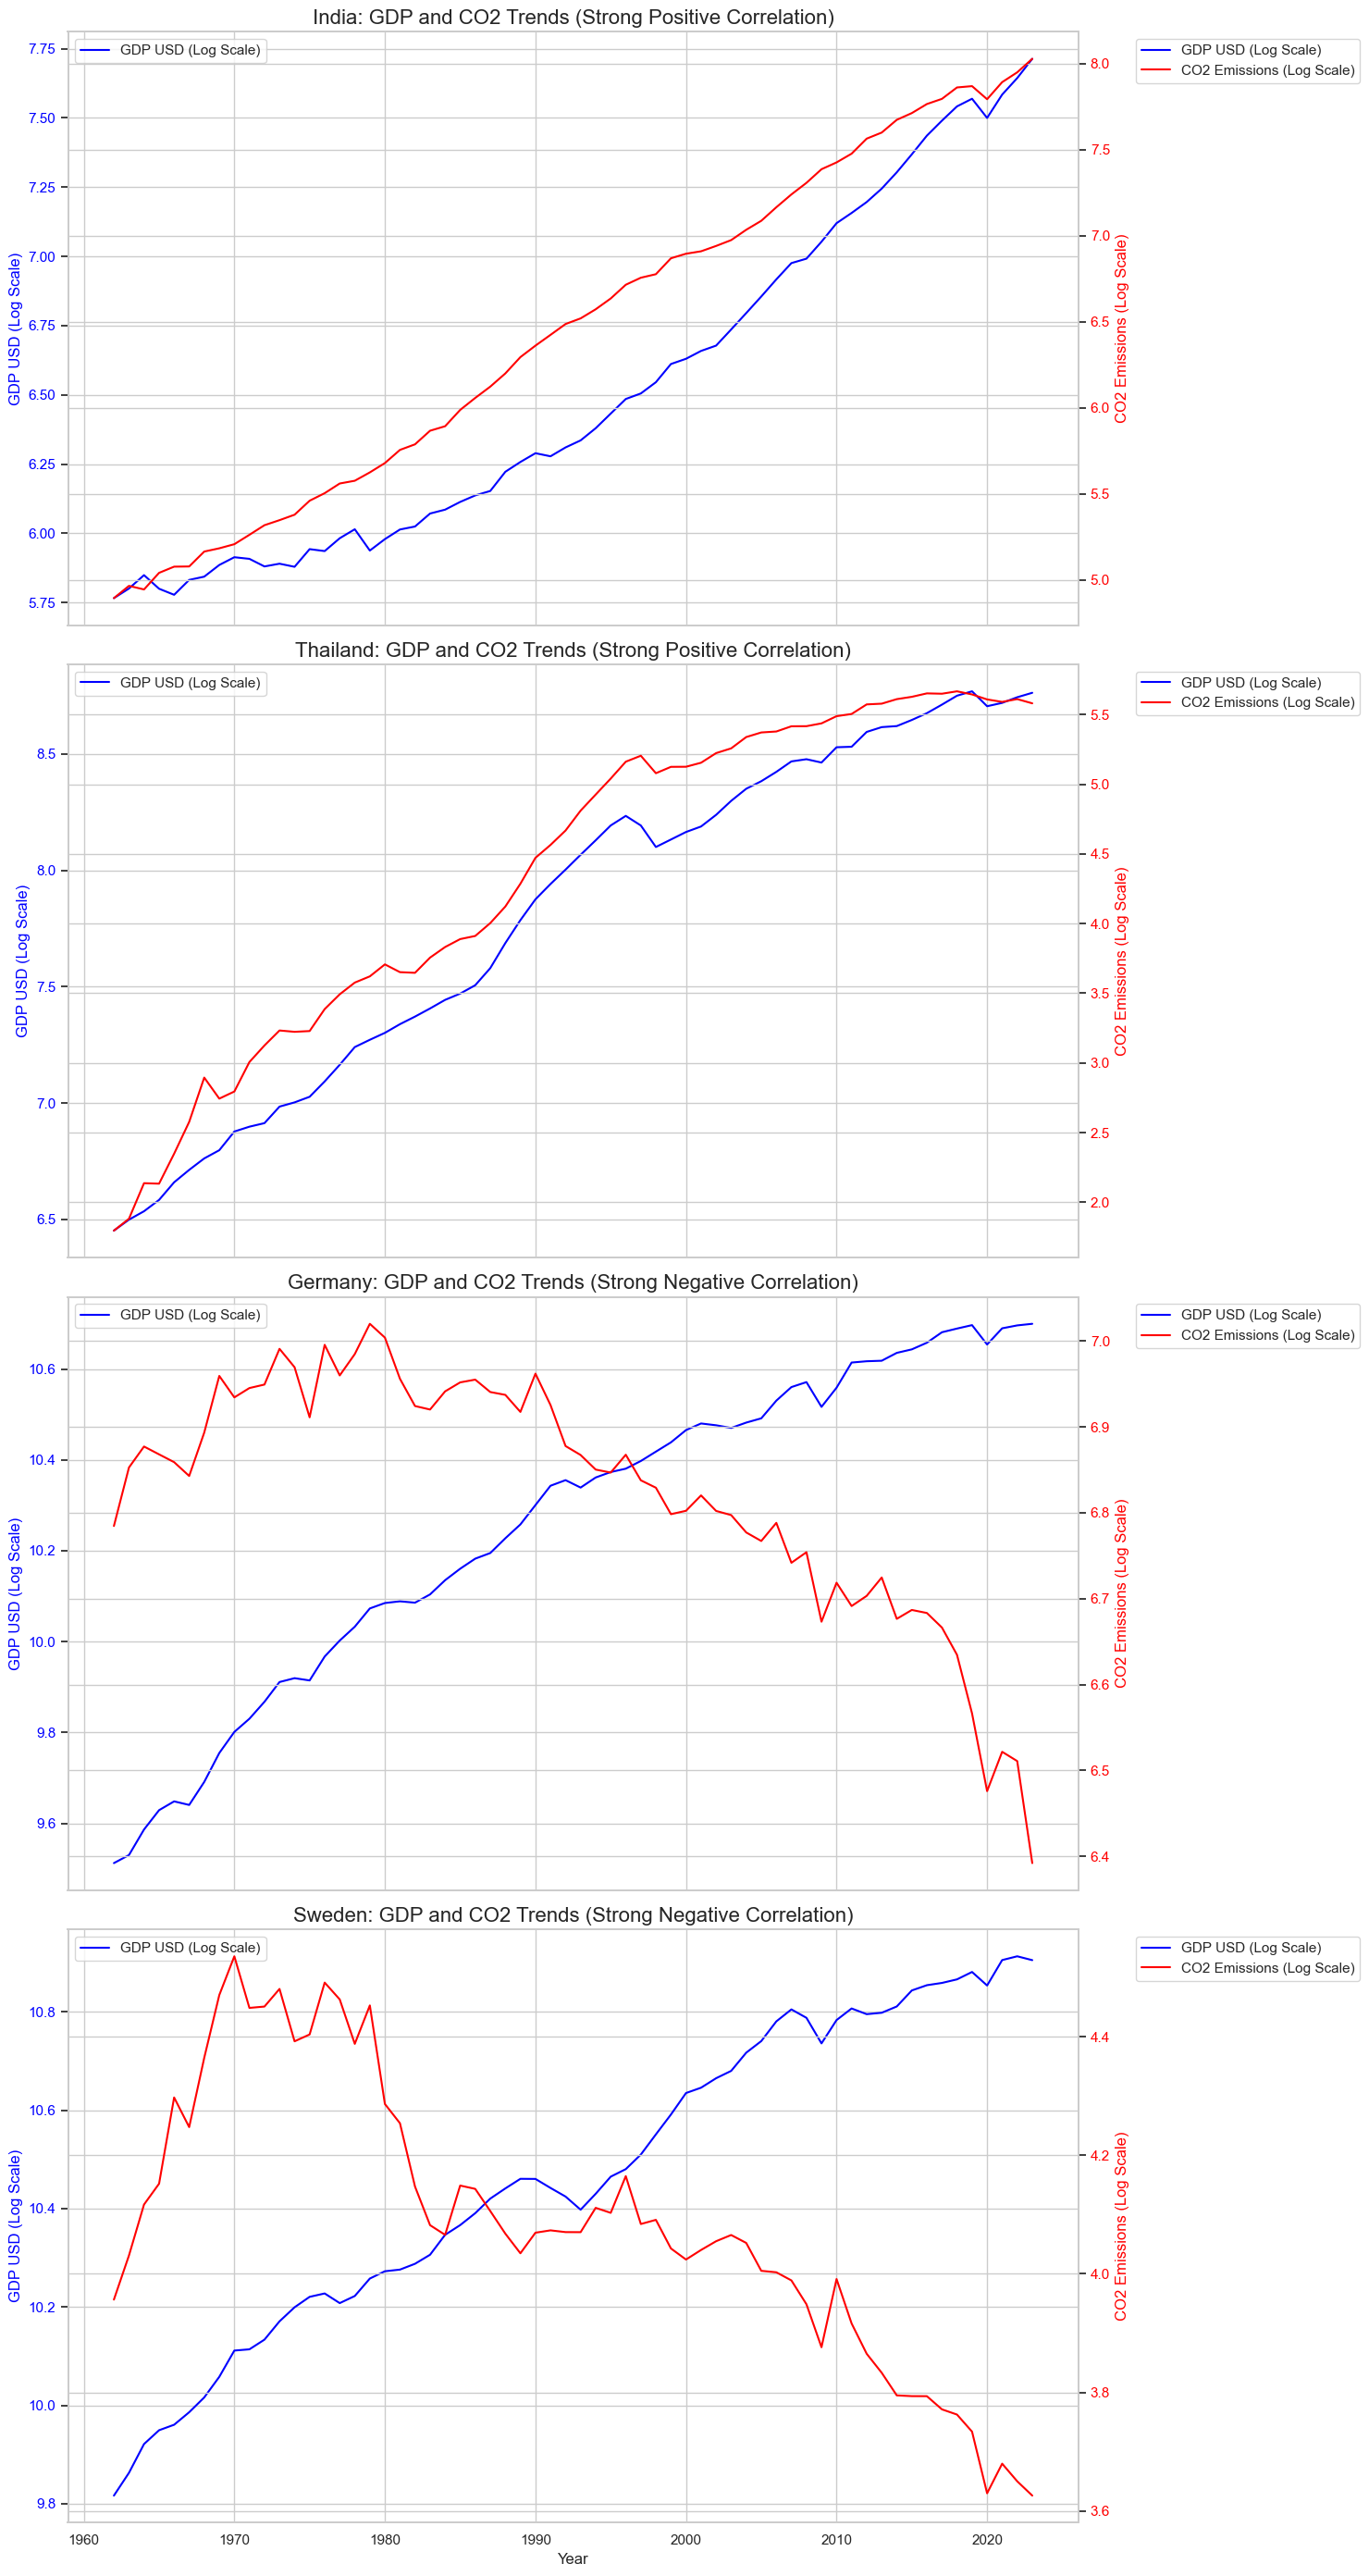

In [18]:
# --- 6. 시각화: 대표 국가별 시계열 추이 (로그 스케일) ---
# 강한 양의 상관관계 및 음의 상관관계를 보이는 대표 국가들을 선정합니다.
representative_countries = {
    "India": "Strong Positive", # 강한 양의 상관관계 국가
    "Thailand": "Strong Positive",
    "Germany": "Strong Negative", # 강한 음의 상관관계 국가 (탈동조화)
    "Sweden": "Strong Negative"
}

fig, axes = plt.subplots(len(representative_countries), 1, figsize=(15, 7 * len(representative_countries)), sharex=True) # figsize 확장
axes = axes.flatten()

for i, (country_name, correlation_type) in enumerate(representative_countries.items()):
    country_data = df_cleaned[df_cleaned['Country Name'] == country_name].sort_values(by='Year')

    # GDP (로그 스케일)
    sns.lineplot(data=country_data, x='Year', y='GDP USD Log', ax=axes[i], label='GDP USD (Log Scale)', color='blue')
    axes[i].set_ylabel('GDP USD (Log Scale)', color='blue', fontsize=12)
    axes[i].tick_params(axis='y', labelcolor='blue')

    # CO2 (로그 스케일) - 보조 Y축 사용
    ax2 = axes[i].twinx()
    sns.lineplot(data=country_data, x='Year', y='CO2 Log', ax=ax2, label='CO2 Emissions (Log Scale)', color='red')
    ax2.set_ylabel('CO2 Emissions (Log Scale)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    # 범례 병합
    lines, labels = axes[i].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

    axes[i].set_title(f'{country_name}: GDP and CO2 Trends ({correlation_type} Correlation)', fontsize=16)
    axes[i].set_xlabel('Year', fontsize=12)

plt.tight_layout()
plt.show()

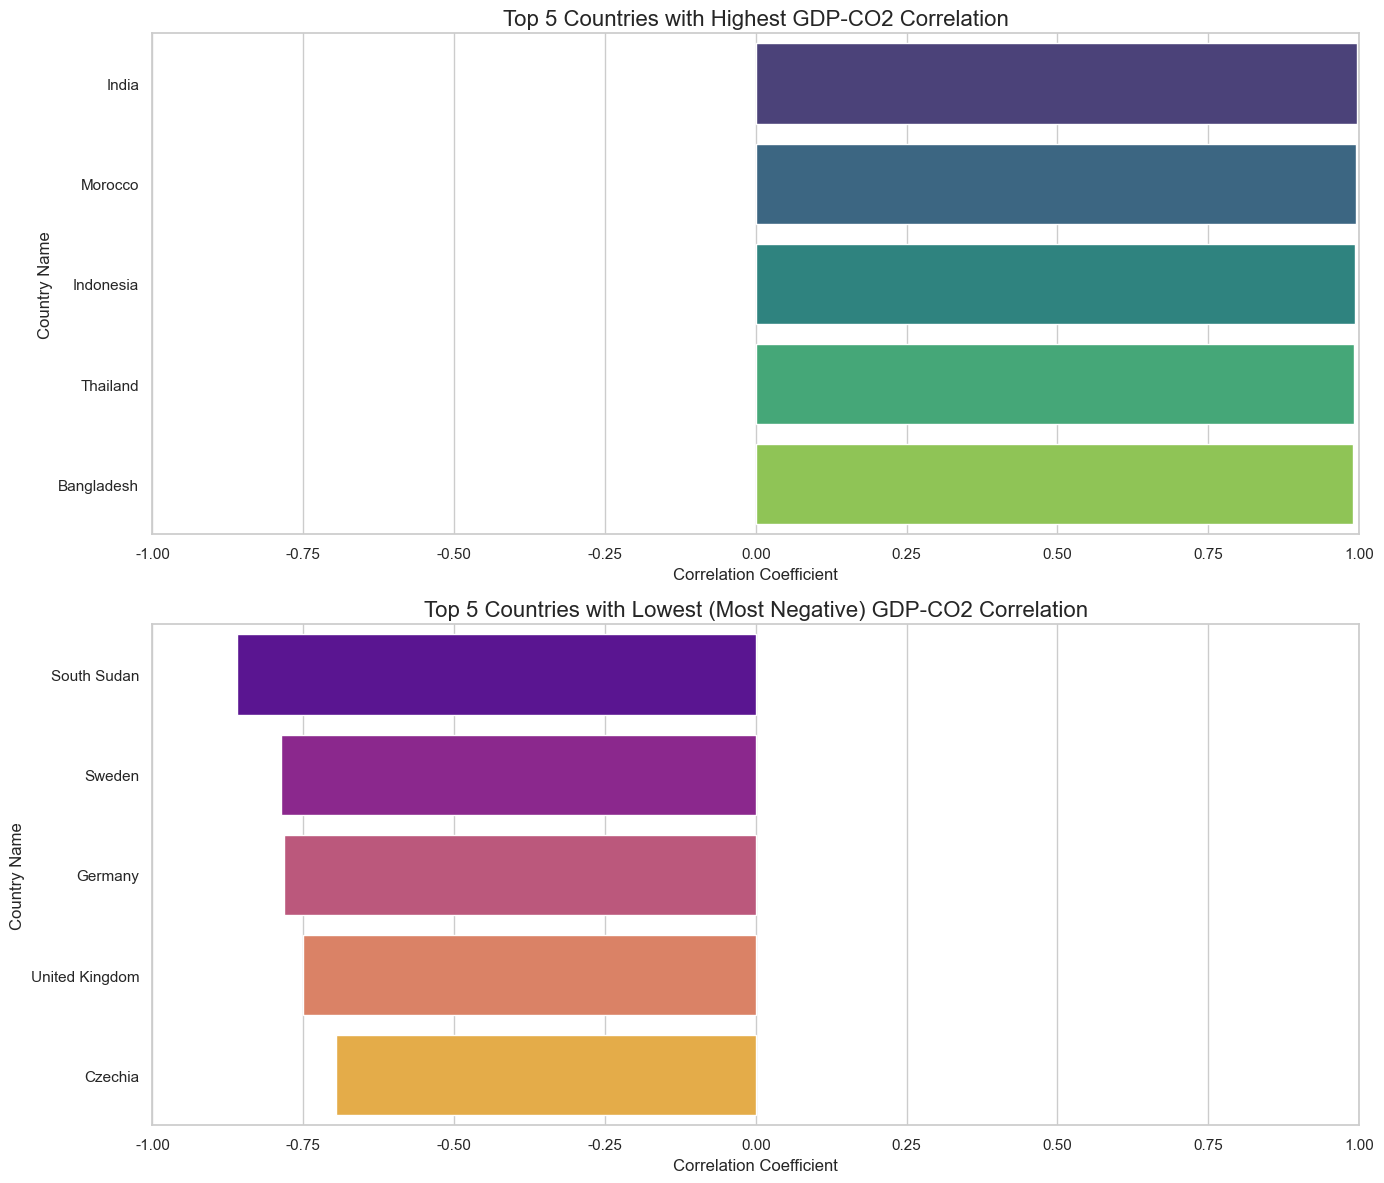

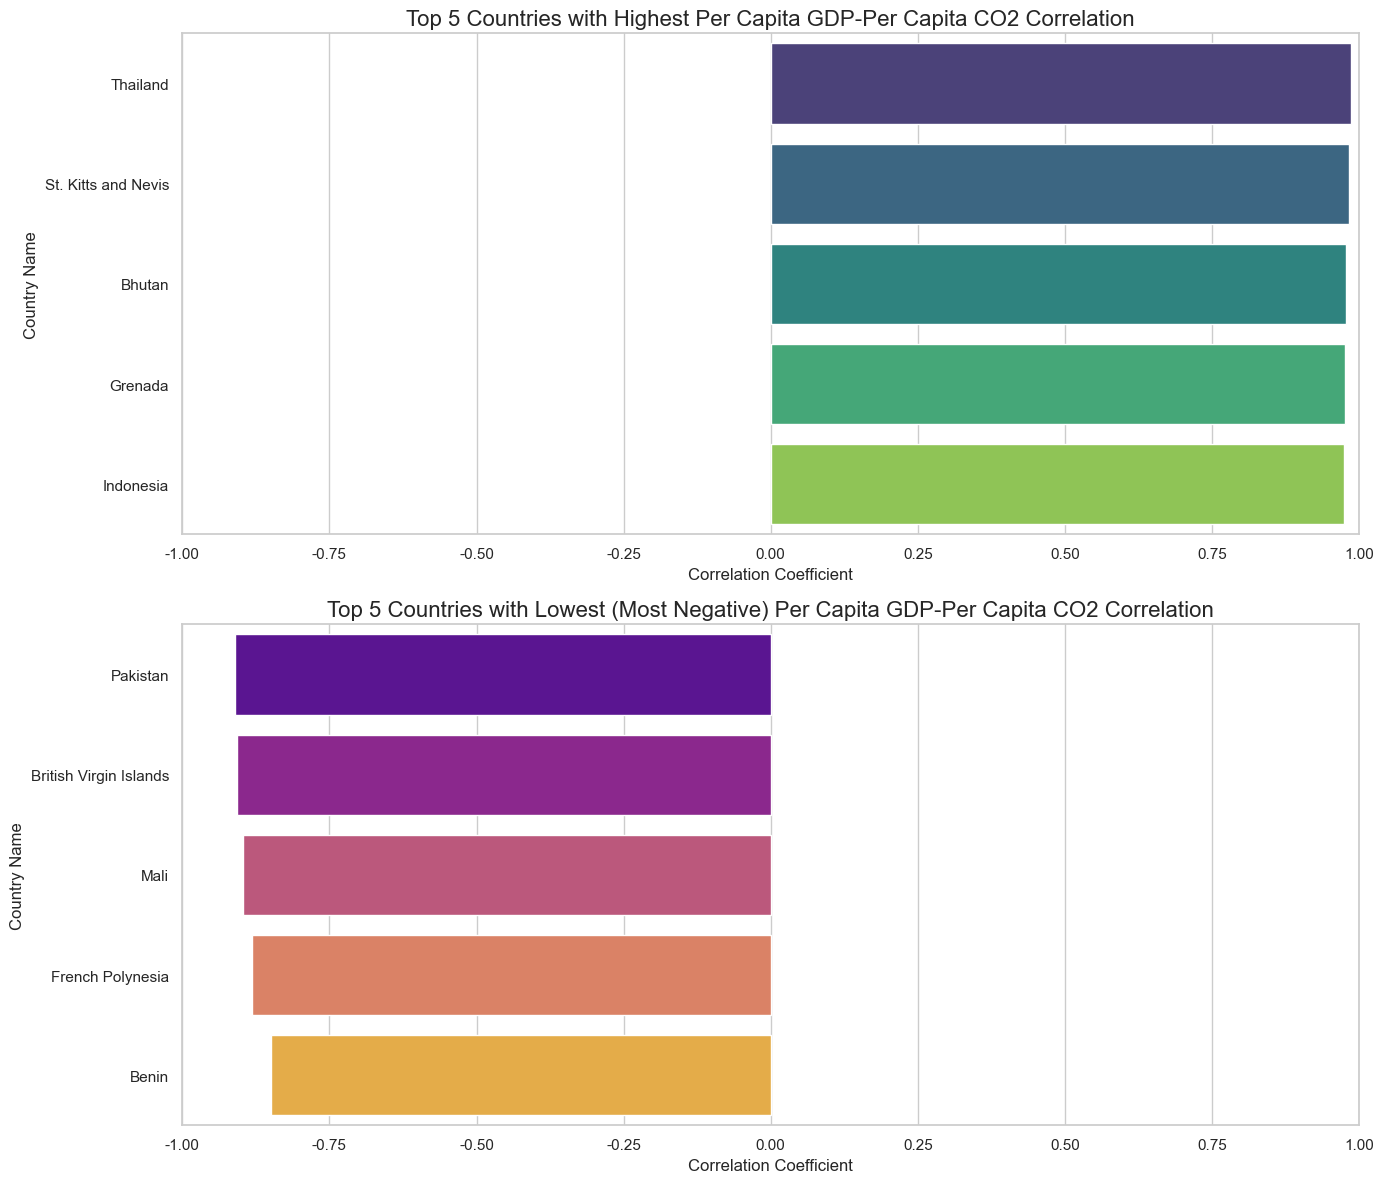

In [19]:
# --- 7. 시각화: 상관관계 상위/하위 5개 국가 (막대 그래프) ---

# 총 GDP-CO2 상관관계 기준 상위/하위 5개 국가
top_5_gdp_co2 = correlations_df.sort_values(by='GDP_CO2_Correlation', ascending=False).head(5)
bottom_5_gdp_co2 = correlations_df.sort_values(by='GDP_CO2_Correlation', ascending=True).head(5)

fig, axes = plt.subplots(2, 1, figsize=(14, 12)) # figsize 확장

# 상위 5개 국가 (총 GDP-CO2)
# legend=False 제거, hue에 x축 변수 할당, dodge=False 추가
sns.barplot(x='GDP_CO2_Correlation', y='Country Name', data=top_5_gdp_co2, ax=axes[0], hue='Country Name', palette='viridis', dodge=False)
if axes[0].legend_: # 범례가 존재하면 제거
    axes[0].legend_.remove()
axes[0].set_title('Top 5 Countries with Highest GDP-CO2 Correlation', fontsize=16)
axes[0].set_xlabel('Correlation Coefficient', fontsize=12)
axes[0].set_ylabel('Country Name', fontsize=12)
axes[0].set_xlim([-1, 1])


# 하위 5개 국가 (총 GDP-CO2)
# legend=False 제거, hue에 x축 변수 할당, dodge=False 추가
sns.barplot(x='GDP_CO2_Correlation', y='Country Name', data=bottom_5_gdp_co2, ax=axes[1], hue='Country Name', palette='plasma', dodge=False)
if axes[1].legend_: # 범례가 존재하면 제거
    axes[1].legend_.remove()
axes[1].set_title('Top 5 Countries with Lowest (Most Negative) GDP-CO2 Correlation', fontsize=16)
axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1].set_ylabel('Country Name', fontsize=12)
axes[1].set_xlim([-1, 1])

plt.tight_layout()
# plt.savefig('top_bottom_gdp_co2_correlations.png') # 이미지 저장 비활성화
# plt.show() # 파이썬 환경에서 바로 보이게 하려면 이 줄을 활성화


# 1인당 GDP-1인당 CO2 상관관계 기준 상위/하위 5개 국가
top_5_pc_gdp_pc_co2 = correlations_df.sort_values(by='GDP_Per_Capita_CO2_Per_Capita_Correlation', ascending=False).head(5)
bottom_5_pc_gdp_pc_co2 = correlations_df.sort_values(by='GDP_Per_Capita_CO2_Per_Capita_Correlation', ascending=True).head(5)

fig, axes = plt.subplots(2, 1, figsize=(14, 12)) # figsize 확장

# 상위 5개 국가 (1인당 GDP-1인당 CO2)
# legend=False 제거, hue에 x축 변수 할당, dodge=False 추가
sns.barplot(x='GDP_Per_Capita_CO2_Per_Capita_Correlation', y='Country Name', data=top_5_pc_gdp_pc_co2, ax=axes[0], hue='Country Name', palette='viridis', dodge=False)
if axes[0].legend_: # 범례가 존재하면 제거
    axes[0].legend_.remove()
axes[0].set_title('Top 5 Countries with Highest Per Capita GDP-Per Capita CO2 Correlation', fontsize=16)
axes[0].set_xlabel('Correlation Coefficient', fontsize=12)
axes[0].set_ylabel('Country Name', fontsize=12)
axes[0].set_xlim([-1, 1])

# 하위 5개 국가 (1인당 GDP-1인당 CO2)
# legend=False 제거, hue에 x축 변수 할당, dodge=False 추가
sns.barplot(x='GDP_Per_Capita_CO2_Per_Capita_Correlation', y='Country Name', data=bottom_5_pc_gdp_pc_co2, ax=axes[1], hue='Country Name', palette='plasma', dodge=False)
if axes[1].legend_: # 범례가 존재하면 제거
    axes[1].legend_.remove()
axes[1].set_title('Top 5 Countries with Lowest (Most Negative) Per Capita GDP-Per Capita CO2 Correlation', fontsize=16)
axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1].set_ylabel('Country Name', fontsize=12)
axes[1].set_xlim([-1, 1])

plt.tight_layout()
plt.show()

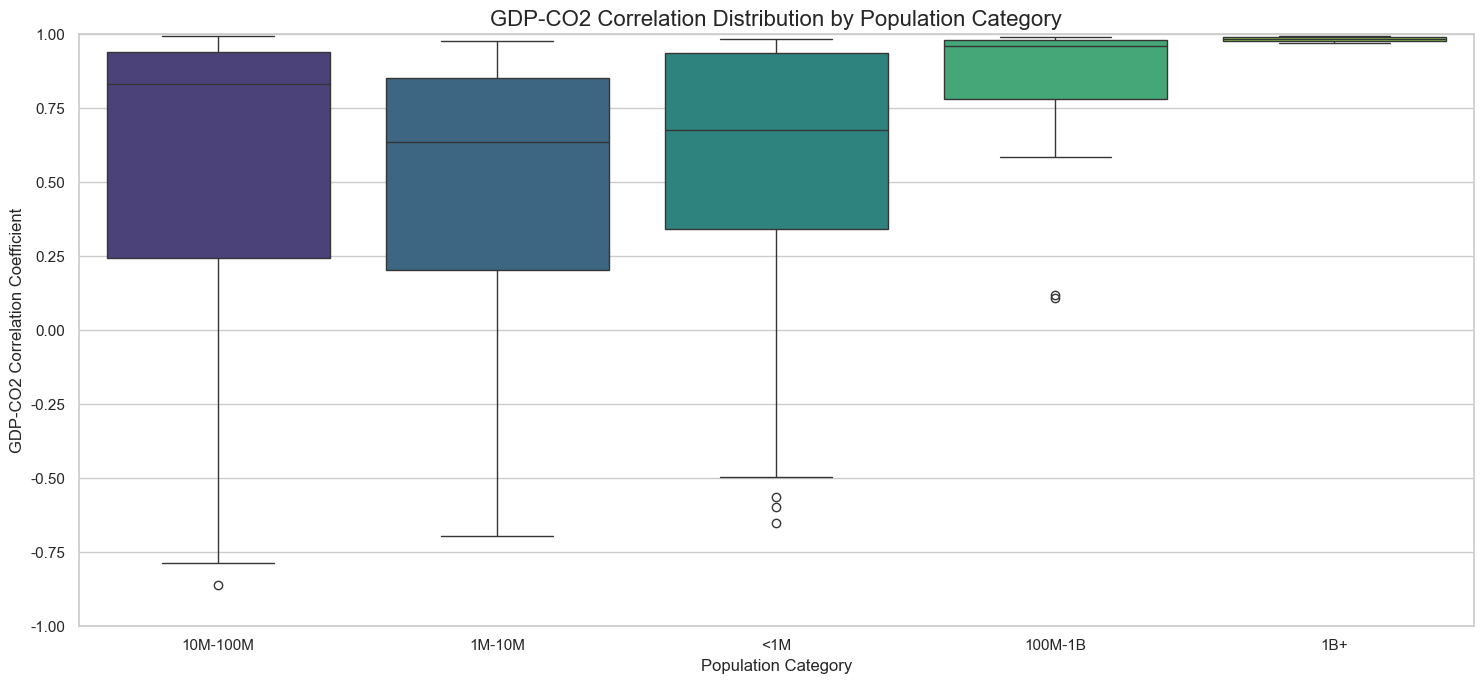

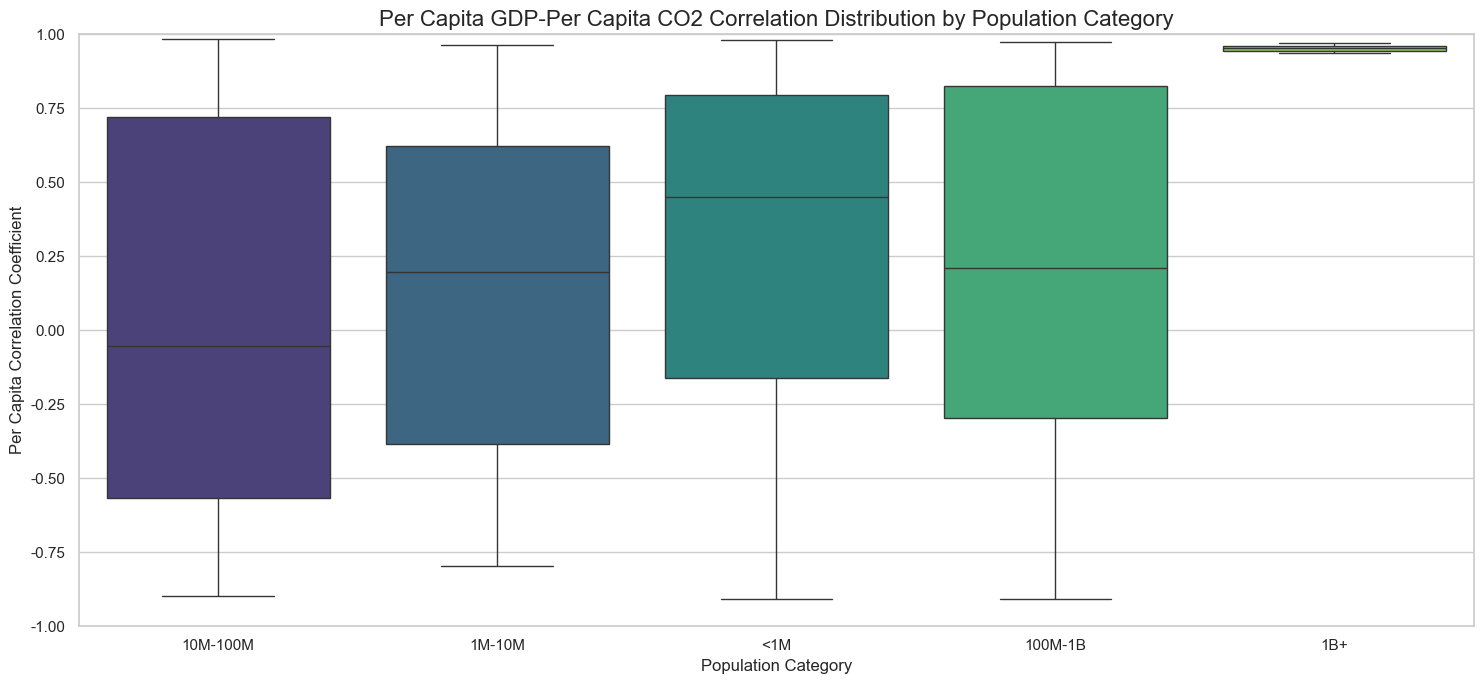

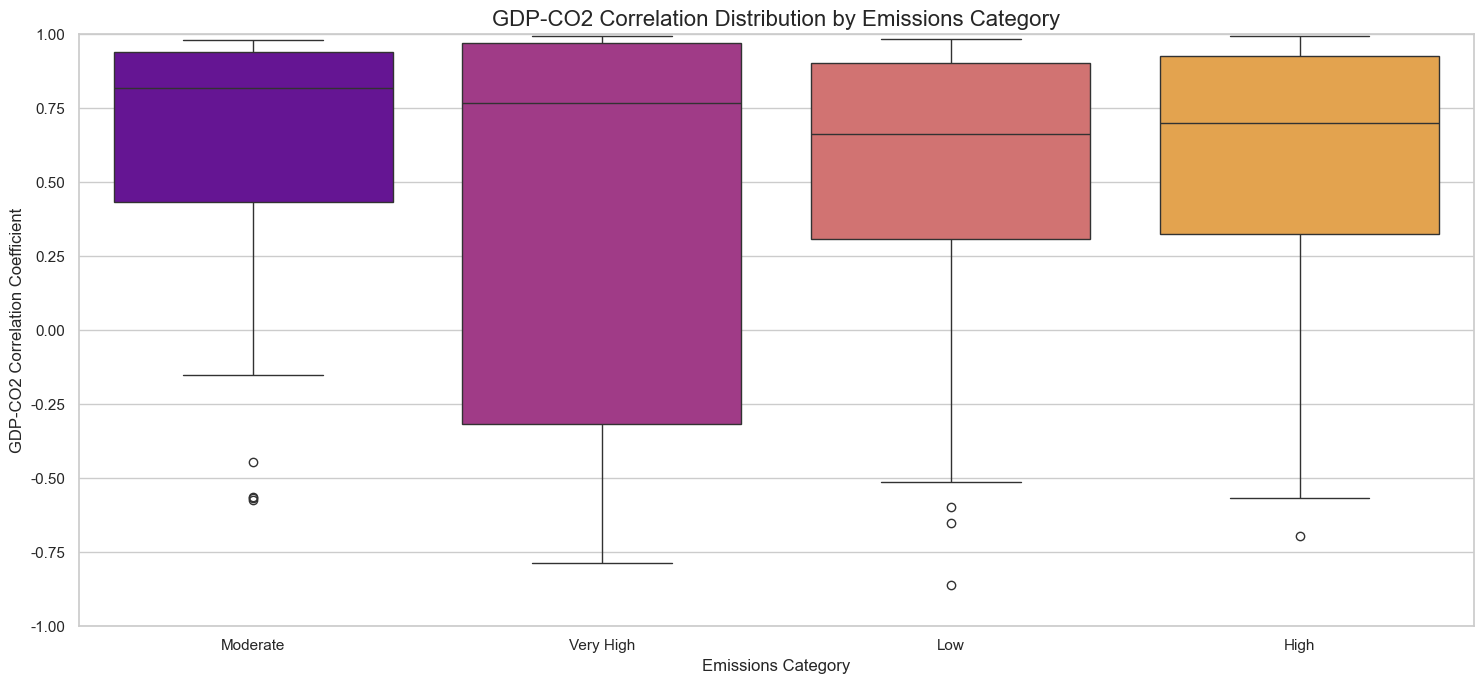

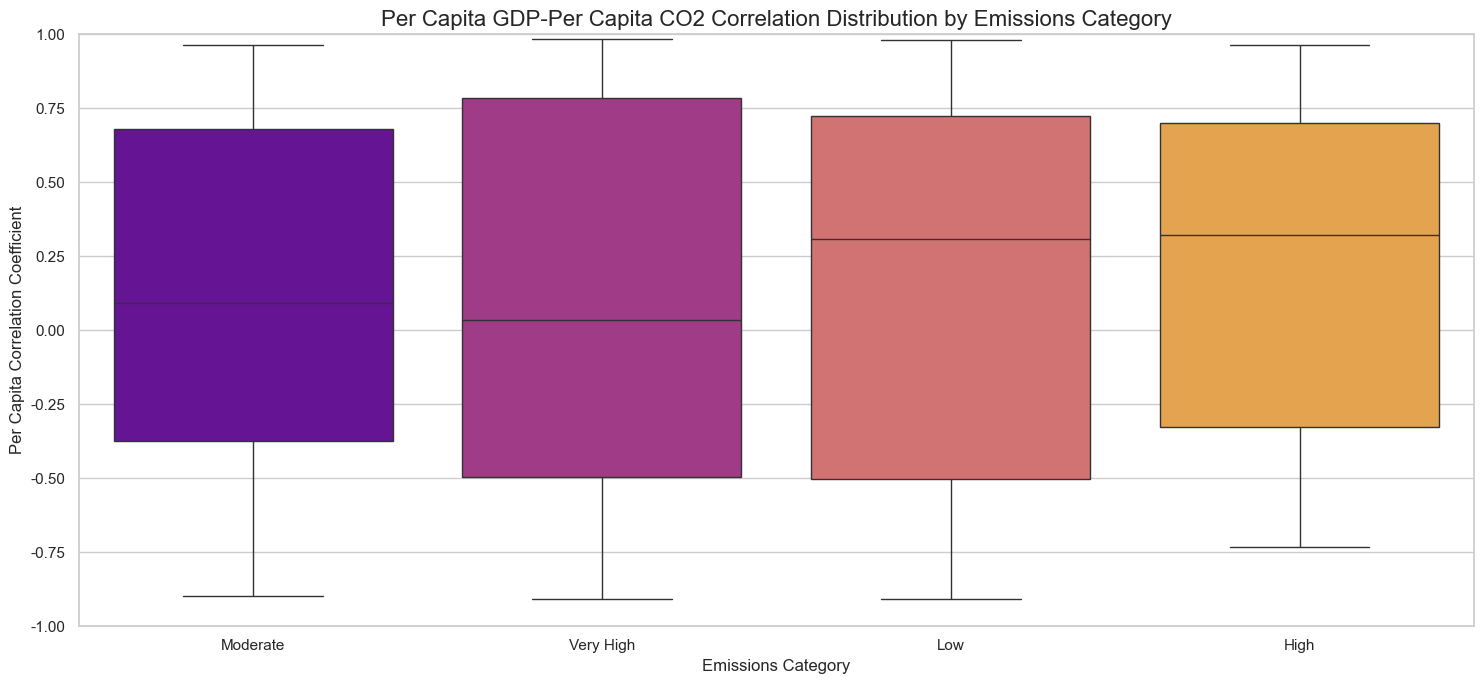

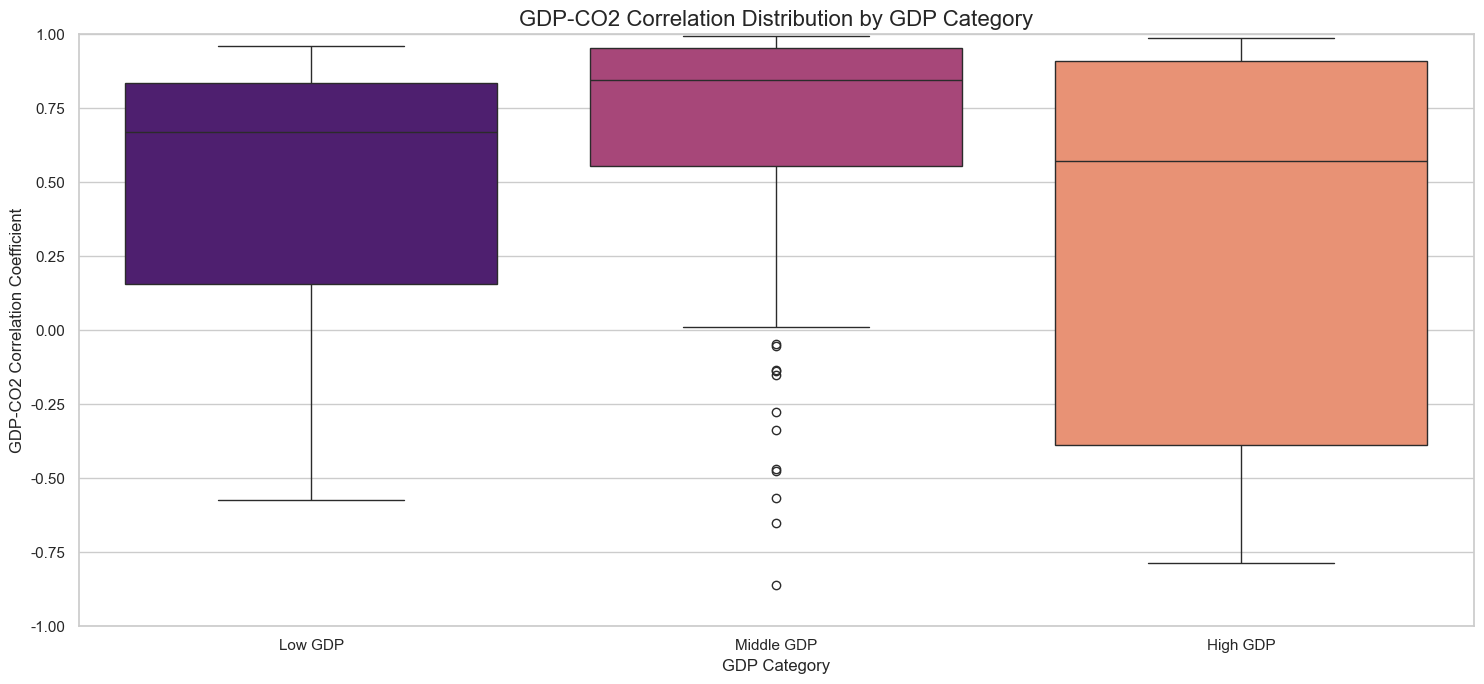

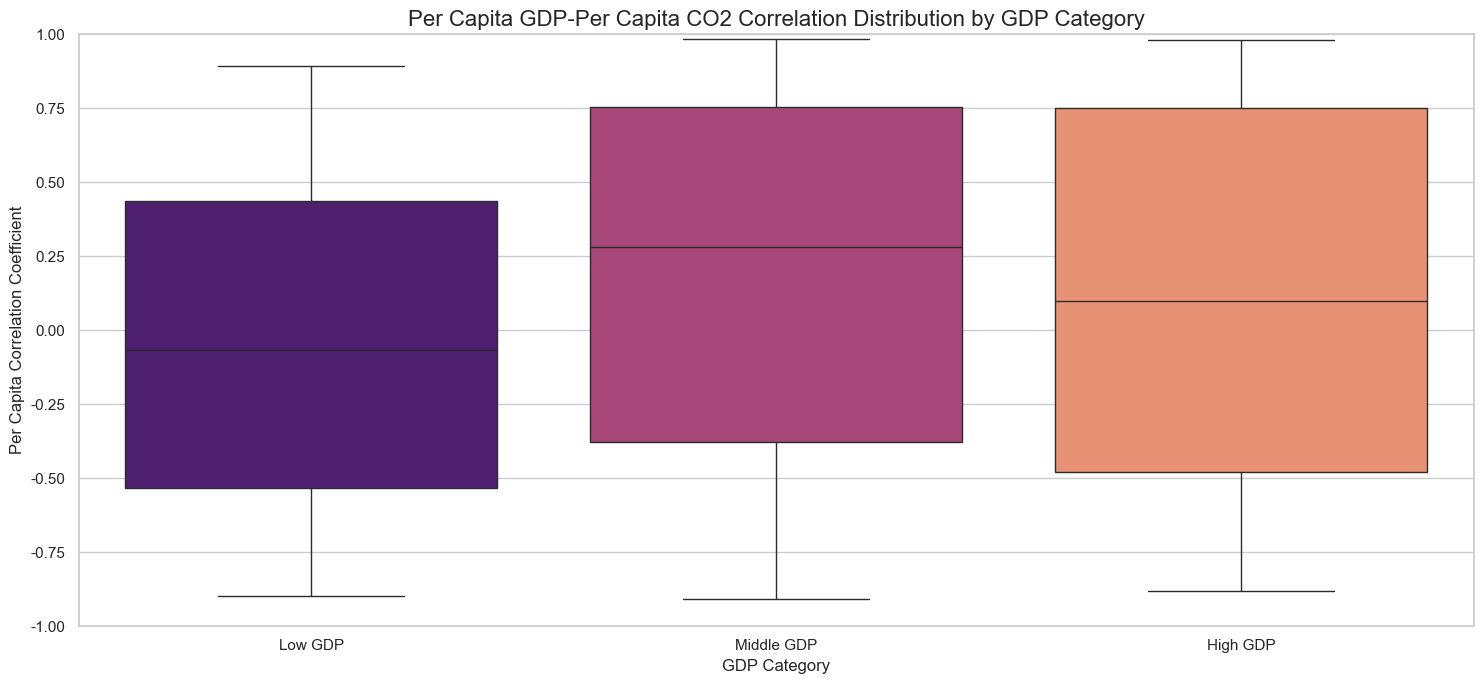

In [21]:
# --- 8. 카테고리별 상관관계 분석 및 시각화 ---

# Pop Category별 상관관계 분석 및 시각화
plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='Pop Category', y='GDP_CO2_Correlation', data=correlations_with_categories_df, hue='Pop Category', legend=False, palette='viridis')
plt.title('GDP-CO2 Correlation Distribution by Population Category', fontsize=16)
plt.xlabel('Population Category', fontsize=12)
plt.ylabel('GDP-CO2 Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
# plt.show()

plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='Pop Category', y='GDP_Per_Capita_CO2_Per_Capita_Correlation', data=correlations_with_categories_df, hue='Pop Category', legend=False, palette='viridis')
plt.title('Per Capita GDP-Per Capita CO2 Correlation Distribution by Population Category', fontsize=16)
plt.xlabel('Population Category', fontsize=12)
plt.ylabel('Per Capita Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
# plt.show()


# Emissions Category별 상관관계 분석 및 시각화
plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='Emissions Category', y='GDP_CO2_Correlation', data=correlations_with_categories_df, hue='Emissions Category', legend=False, palette='plasma')
plt.title('GDP-CO2 Correlation Distribution by Emissions Category', fontsize=16)
plt.xlabel('Emissions Category', fontsize=12)
plt.ylabel('GDP-CO2 Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
# plt.show()

plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='Emissions Category', y='GDP_Per_Capita_CO2_Per_Capita_Correlation', data=correlations_with_categories_df, hue='Emissions Category', legend=False, palette='plasma')
plt.title('Per Capita GDP-Per Capita CO2 Correlation Distribution by Emissions Category', fontsize=16)
plt.xlabel('Emissions Category', fontsize=12)
plt.ylabel('Per Capita Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
# plt.show()


# GDP Category별 상관관계 분석 및 시각화
plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='GDP Category', y='GDP_CO2_Correlation', data=correlations_with_categories_df, hue='GDP Category', legend=False, palette='magma')
plt.title('GDP-CO2 Correlation Distribution by GDP Category', fontsize=16)
plt.xlabel('GDP Category', fontsize=12)
plt.ylabel('GDP-CO2 Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
# plt.show()

plt.figure(figsize=(15, 7)) # figsize 확장
sns.boxplot(x='GDP Category', y='GDP_Per_Capita_CO2_Per_Capita_Correlation', data=correlations_with_categories_df, hue='GDP Category', legend=False, palette='magma')
plt.title('Per Capita GDP-Per Capita CO2 Correlation Distribution by GDP Category', fontsize=16)
plt.xlabel('GDP Category', fontsize=12)
plt.ylabel('Per Capita Correlation Coefficient', fontsize=12)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

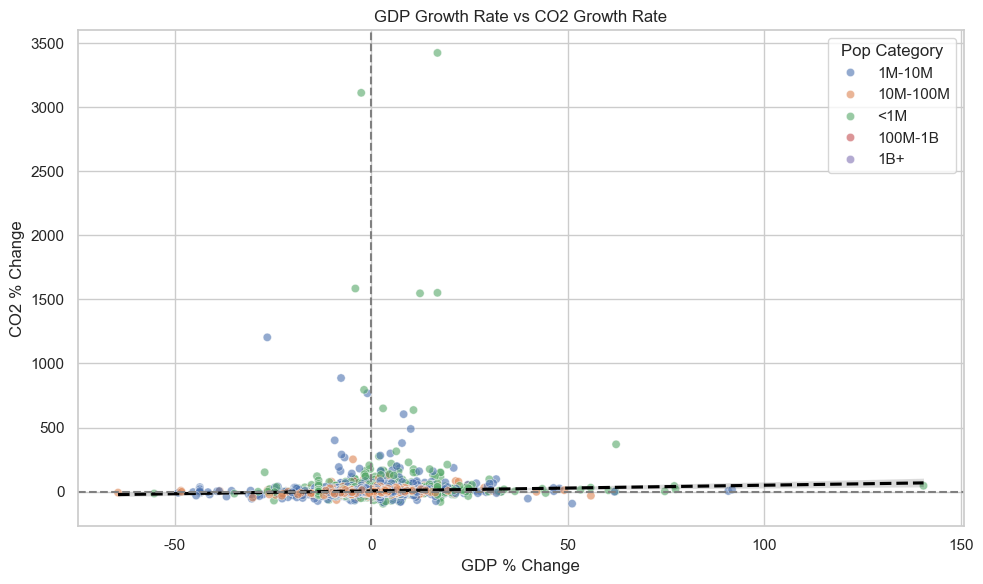

In [22]:
#추가 시각자료

import matplotlib.pyplot as plt
import platform
import seaborn as sns
import numpy as np

# macOS 유니코드 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'Arial Unicode MS'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 결측치 및 inf 값 처리
df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan)
df_cleaned = df_cleaned.dropna(subset=['GDP %', 'CO2 %'])

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='GDP %', y='CO2 %', hue='Pop Category', alpha=0.6)
sns.regplot(data=df_cleaned, x='GDP %', y='CO2 %', scatter=False, color='black', line_kws={'linestyle': '--'})

plt.title('GDP Growth Rate vs CO2 Growth Rate')
plt.xlabel('GDP % Change')
plt.ylabel('CO2 % Change')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.tight_layout()
plt.show()

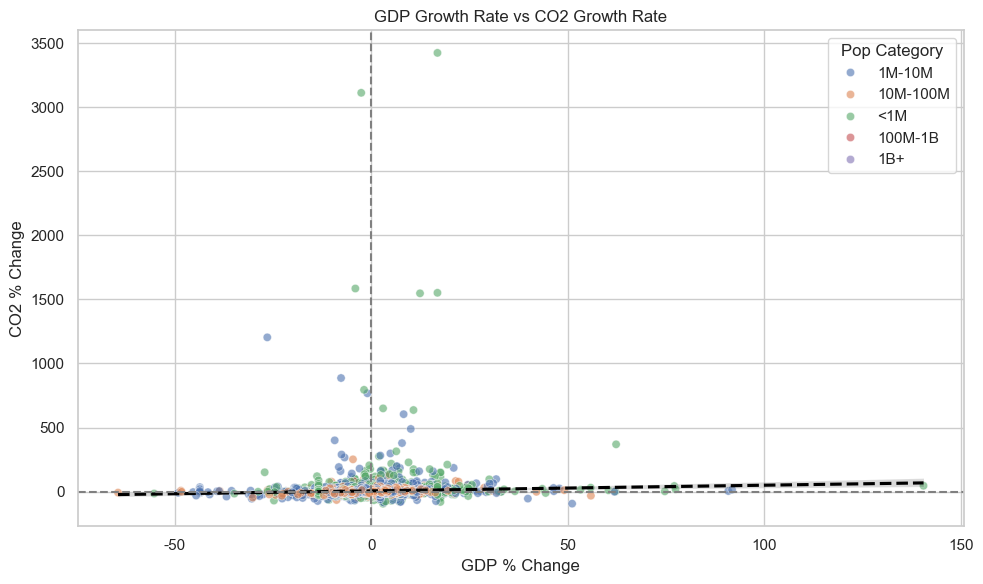

In [24]:
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import numpy as np

# --- 필요한 데이터프레임 (df_cleaned)이 이전에 성공적으로 생성되었다고 가정합니다.
# --- 만약 이 코드를 독립적으로 실행할 경우, 위쪽의 데이터 로드 및 전처리 코드를 먼저 실행해야 합니다.

# macOS 유니코드 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'Arial Unicode MS'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 결측치 및 inf 값 처리
# df_cleaned는 이전에 전처리된 상태여야 하지만, 이 코드 블록만 실행될 경우를 대비하여
# 잠재적 무한대 값을 NaN으로 처리하고, 핵심 컬럼의 NaN을 다시 제거합니다.
df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan)
df_cleaned = df_cleaned.dropna(subset=['GDP %', 'CO2 %', 'Pop Category']) # Pop Category도 hue로 사용되므로 함께 처리

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='GDP %', y='CO2 %', hue='Pop Category', alpha=0.6)
sns.regplot(data=df_cleaned, x='GDP %', y='CO2 %', scatter=False, color='black', line_kws={'linestyle': '--'})

plt.title('GDP Growth Rate vs CO2 Growth Rate')
plt.xlabel('GDP % Change')
plt.ylabel('CO2 % Change')

plt.axhline(0, color='grey', linestyle='--') # Y축 0 기준선
plt.axvline(0, color='grey', linestyle='--') # X축 0 기준선

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd
from scipy.stats import ttest_ind

# 비교할 카테고리 컬럼과 그룹쌍 설정
category_info = {
    'GDP Category': ('High GDP', 'Low GDP'),
    'Emissions Category': ('Very High', 'Low')
}

target_metric = 'CO2'  # 1인당 CO₂ 배출량

results = []

for category_col, (group1, group2) in category_info.items():
    group1_data = df[df[category_col] == group1][target_metric]
    group2_data = df[df[category_col] == group2][target_metric]

    t_stat, p_val = ttest_ind(group1_data, group2_data, equal_var=False)

    results.append({
        '비교 항목': category_col,
        'Group 1': group1,
        'Group 2': group2,
        'Group1 평균': round(group1_data.mean()),
        'Group2 평균': round(group2_data.mean()),
        't-stat': round(t_stat, 2),
        'p-value': round(p_val, 4),
        '유의성': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df)

                비교 항목    Group 1  Group 2  Group1 평균  Group2 평균  t-stat  \
0        GDP Category   High GDP  Low GDP        215         31   13.58   
1  Emissions Category  Very High      Low        450          0   22.80   

   p-value  유의성  
0      0.0  Yes  
1      0.0  Yes  


In [39]:
print(len(df[df['GDP Category'] == 'High']))
print(len(df[df['GDP Category'] == 'Low']))

0
0
